In [1]:
# IMPORT CÁC THƯ VIỆN CẦN THIẾT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
# CÂU 1: KHỞI TẠO DỮ LIỆU (Data Generation)
np.random.seed(42) # Cố định seed để kết quả đồng nhất
n = 500

# Tạo các cột dữ liệu theo yêu cầu
ma_kh = [f'KH{i:03d}' for i in range(1, n + 1)]
tuoi = np.random.randint(18, 71, size=n).astype(float)
# Chèn cố tình 10 giá trị NaN vào cột Tuoi
tuoi[np.random.choice(n, 10, replace=False)] = np.nan

thu_nhap = np.random.uniform(5, 50, size=n)
# Tạo 5 giá trị cực trị lên tới 200 triệu cho cột ThuNhap
thu_nhap[np.random.choice(n, 5, replace=False)] = np.random.uniform(150, 200, size=5)

gioi_tinh = np.random.choice(['Nam', 'Nữ'], size=n).astype(object)
# Chèn cố tình 15 giá trị NaN vào cột GioiTinh
gioi_tinh[np.random.choice(n, 15, replace=False)] = np.nan

thanh_pho = np.random.choice(['Hà Nội', 'Đà Nẵng', 'TP.HCM'], size=n)

# TongChiTieu tương quan nhẹ với ThuNhap
tong_chi_tieu = thu_nhap * np.random.uniform(0.3, 0.7, size=n) + np.random.normal(0, 2, size=n)
tong_chi_tieu = np.abs(tong_chi_tieu)

# Tạo DataFrame
df_khachhang = pd.DataFrame({
    'MaKH': ma_kh,
    'Tuoi': tuoi,
    'ThuNhap': thu_nhap,
    'GioiTinh': gioi_tinh,
    'ThanhPho': thanh_pho,
    'TongChiTieu': tong_chi_tieu
})

print("--- THỐNG KÊ GIÁ TRỊ KHUYẾT TRƯỚC XỬ LÝ ---")
print(df_khachhang.isnull().sum())

# CÂU 2: XỬ LÝ GIÁ TRỊ KHUYẾT (Missing Values)
# Điền khuyết cột Tuoi bằng Trung vị
df_khachhang['Tuoi'] = df_khachhang['Tuoi'].fillna(df_khachhang['Tuoi'].median())
# Điền khuyết cột GioiTinh bằng Mode
df_khachhang['GioiTinh'] = df_khachhang['GioiTinh'].fillna(df_khachhang['GioiTinh'].mode()[0])

print("\n--- THỐNG KÊ GIÁ TRỊ KHUYẾT SAU XỬ LÝ ---")
print(df_khachhang.isnull().sum())

--- THỐNG KÊ GIÁ TRỊ KHUYẾT TRƯỚC XỬ LÝ ---
MaKH            0
Tuoi           10
ThuNhap         0
GioiTinh       15
ThanhPho        0
TongChiTieu     0
dtype: int64

--- THỐNG KÊ GIÁ TRỊ KHUYẾT SAU XỬ LÝ ---
MaKH           0
Tuoi           0
ThuNhap        0
GioiTinh       0
ThanhPho       0
TongChiTieu    0
dtype: int64


In [3]:
# CÂU 3: MÃ HÓA BIẾN PHÂN LOẠI
# Sử dụng pd.get_dummies cho cột ThanhPho và gộp vào DataFrame gốc
dummies = pd.get_dummies(df_khachhang['ThanhPho'], prefix='ThanhPho', dtype=int)
df_khachhang = pd.concat([df_khachhang, dummies], axis=1)

# CÂU 4: PHÁT HIỆN VÀ XỬ LÝ ĐIỂM DỊ BIỆT (Outlier Detection)
# Dùng phương pháp Khoảng tứ phân vị (IQR) cho cột ThuNhap
Q1 = df_khachhang['ThuNhap'].quantile(0.25)
Q3 = df_khachhang['ThuNhap'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Lọc bỏ các dòng có giá trị ThuNhap là Outlier
so_luong_truoc = len(df_khachhang)
df_khachhang = df_khachhang[(df_khachhang['ThuNhap'] >= lower_bound) & (df_khachhang['ThuNhap'] <= upper_bound)]
print(f"Đã xóa {so_luong_truoc - len(df_khachhang)} dòng chứa Outlier của ThuNhap.")

# CÂU 5: CHUẨN HÓA DỮ LIỆU (Feature Scaling)
scaler = MinMaxScaler()
# Chuẩn hóa cột TongChiTieu về [0, 1]
df_khachhang['TongChiTieu_Scaled'] = scaler.fit_transform(df_khachhang[['TongChiTieu']])

Đã xóa 5 dòng chứa Outlier của ThuNhap.


In [4]:
# CÂU 6: LỌC DỮ LIỆU THEO ĐIỀU KIỆN
# Khách hàng là 'Nữ', Tuoi > 30, đang ở 'Hà Nội'
df_phu = df_khachhang[(df_khachhang['GioiTinh'] == 'Nữ') &
                      (df_khachhang['Tuoi'] > 30) &
                      (df_khachhang['ThanhPho'] == 'Hà Nội')]
print("--- 5 DÒNG ĐẦU TIÊN CỦA KẾT QUẢ LỌC ---")
display(df_phu.head())

# CÂU 7: GOM NHÓM VÀ THỐNG KÊ (Aggregation)
# Tính Trung bình (Mean) và Tổng (Sum) của TongChiTieu theo từng ThanhPho
thong_ke = df_khachhang.groupby('ThanhPho')['TongChiTieu'].agg(['mean', 'sum'])
print("\n--- THỐNG KÊ TỔNG CHI TIÊU THEO THÀNH PHỐ ---")
print(thong_ke)

# CÂU 8: KỸ NGHỆ ĐẶC TRƯNG (Feature Engineering)
# Tạo cột NhomTuoi dựa trên các khoảng yêu cầu
bins = [0, 30, 45, 60, 150]
labels = ['18-30', '31-45', '46-60', 'Trên 60']
df_khachhang['NhomTuoi'] = pd.cut(df_khachhang['Tuoi'], bins=bins, labels=labels)

--- 5 DÒNG ĐẦU TIÊN CỦA KẾT QUẢ LỌC ---


,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu,ThanhPho_Hà Nội,ThanhPho_TP.HCM,ThanhPho_Đà Nẵng,TongChiTieu_Scaled
0,KH001,56.0,19.865682,Nữ,Hà Nội,8.428783,1,0,0,0.208308
8,KH009,36.0,41.263920,Nữ,Hà Nội,20.286109,1,0,0,0.528062
12,KH013,41.0,5.820912,Nữ,Hà Nội,2.132457,1,0,0,0.038515
16,KH017,41.0,30.919929,Nữ,Hà Nội,22.280101,1,0,0,0.581834
19,KH020,70.0,48.878022,Nữ,Hà Nội,26.974007,1,0,0,0.708414



--- THỐNG KÊ TỔNG CHI TIÊU THEO THÀNH PHỐ ---
               mean          sum
ThanhPho                        
Hà Nội    14.260564  2538.380349
TP.HCM    14.430370  2395.441386
Đà Nẵng   14.292095  2158.106392


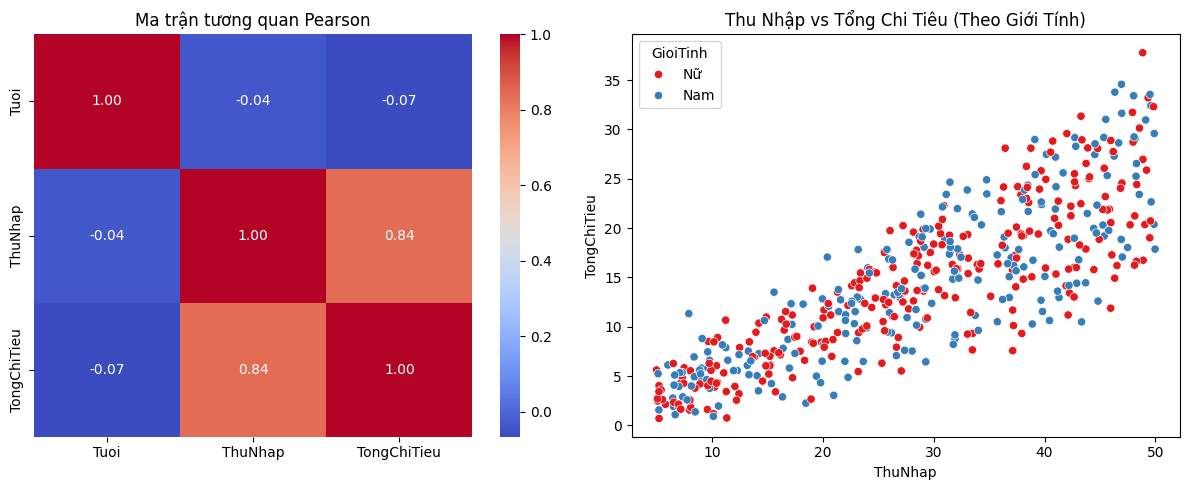

In [5]:
# CÂU 9: MA TRẬN TƯƠNG QUAN
# Tính ma trận tương quan Pearson
corr_matrix = df_khachhang[['Tuoi', 'ThuNhap', 'TongChiTieu']].corr()

plt.figure(figsize=(12, 5))

# Vẽ Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan Pearson')

# CÂU 10: TRỰC QUAN HÓA DỮ LIỆU (Scatter Plot)
# Vẽ Scatter Plot ThuNhap và TongChiTieu, phân màu theo GioiTinh
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_khachhang, x='ThuNhap', y='TongChiTieu', hue='GioiTinh', palette='Set1')
plt.title('Thu Nhập vs Tổng Chi Tiêu (Theo Giới Tính)')

plt.tight_layout()
plt.show()

In [6]:
# CÂU 11: XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH CNN
print("--- ĐANG TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU FASHION MNIST ---")
# 1. Tiền xử lý
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Chuẩn hóa (scale) giá trị pixel về khoảng [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape thêm kênh màu để phù hợp đầu vào CNN (28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 2. Xây dựng kiến trúc CNN
model = Sequential([
    # Lớp Tích chập (Conv2D) 32 filters, kernel 3x3, ReLU
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    # Lớp Pooling (MaxPooling2D)
    MaxPooling2D(pool_size=(2, 2)),
    # Lớp Flatten để duỗi dữ liệu
    Flatten(),
    # Lớp ẩn (Dense) 64 units, ReLU
    Dense(64, activation='relu'),
    # Lớp đầu ra 10 units, Softmax
    Dense(10, activation='softmax')
])

# 3. Biên dịch và Huấn luyện
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\n--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH ---")
# Fit mô hình trên tập train trong 5 epochs
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

# 4. Đánh giá
print("\n--- ĐÁNH GIÁ MÔ HÌNH ---")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Độ chính xác trên tập kiểm thử (Accuracy): {test_acc * 100:.2f}%")

--- ĐANG TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU FASHION MNIST ---
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH ---
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.8529 - loss: 0.4187 - val_accuracy: 0.8860 - val_loss: 0.3260
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.8965 - loss: 0.2871 - val_accuracy: 0.9067 - val_loss: 0.2707
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9110 - loss: 0.2456 - val_accuracy: 0.9058 - val_loss: 0.2656
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9227 - loss: 0.2125 - val_accuracy: 0.9063 - val_loss: 0.2578
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9307 - loss: 0.1911 - val_accuracy: 0.9093 - val_loss: 0.2526

--- ĐÁNH GIÁ MÔ HÌNH ---
Độ chính xác trên tập kiểm thử (Accuracy): 90.57%
